In [ ]:
import pandas as pd

tasks = pd.DataFrame({
    "Tache": [
        "A - Définition projet crypto BTC",
        "B - Scraping données web (prix/infos crypto)",
        "C - Récupération données API Binance",
        "D - Fusion et nettoyage des données",
        "E - Calcul indicateurs techniques (RSI, MACD...)",
        "F - Création labels CT / MT / LT",
        "G - Préprocessing données (scaling + séquences)",
        "H - Entraînement modèle LSTM",
        "I - Évaluation modèle",
        "J - Visualisation données et indicateurs",
        "K - Application Streamlit",
        "L - Réflexion optimisation (planning théorique)"
    ],
    "Duree": [2, 2, 3, 1, 3, 1, 1, 3, 1, 1, 2, 2],
    "Predecesseurs": [
        "",       # A
        "A",      # B (scraping dépend du projet)
        "A",      # C (API aussi)
        "B,C",    # D (fusion des sources)
        "D",      # E
        "E",      # F
        "F",      # G
        "G",      # H
        "H",      # I
        "E",      # J (parallèle)
        "I,J",    # K
        "H"       # L (parallèle)
    ]
})

tasks

,Tache,Duree,Predecesseurs
0,A - Conception,2,
1,B - Récupération données,3,A
2,C - Feature engineering,3,B
3,D - Préprocessing,1,C
4,E - Modélisation LSTM,4,D
5,F - Visualisation,1,E
6,G - Application Streamlit,2,F
7,H - Optimisation (théorique),2,G


In [9]:
tasks["ES"] = 0
tasks["EF"] = 0

for i in range(len(tasks)):
    preds = tasks.loc[i, "Predecesseurs"]
    
    if preds == "":
        ES = 0
    else:
        preds_list = preds.split(",")
        ES = max(tasks[tasks["Tache"].str[0].isin(preds_list)]["EF"])
    
    tasks.loc[i, "ES"] = ES
    tasks.loc[i, "EF"] = ES + tasks.loc[i, "Duree"]

tasks

,Tache,Duree,Predecesseurs,ES,EF
0,A - Conception,2,,0,2
1,B - Récupération données,3,A,2,5
2,C - Feature engineering,3,B,5,8
3,D - Préprocessing,1,C,8,9
4,E - Modélisation LSTM,4,D,9,13
5,F - Visualisation,1,E,13,14
6,G - Application Streamlit,2,F,14,16
7,H - Optimisation (théorique),2,G,16,18


In [11]:
tasks["LF"] = tasks["EF"].max()
tasks["LS"] = 0

for i in reversed(range(len(tasks))):
    current_task = tasks.loc[i, "Tache"][0]
    
    successeurs = tasks[tasks["Predecesseurs"].str.contains(current_task, na=False)]
    
    if len(successeurs) == 0:
        LF = tasks["EF"].max()
    else:
        LF = min(successeurs["LS"])
    
    tasks.loc[i, "LF"] = LF
    tasks.loc[i, "LS"] = LF - tasks.loc[i, "Duree"]

tasks

,Tache,Duree,Predecesseurs,ES,EF,LF,LS
0,A - Conception,2,,0,2,2,0
1,B - Récupération données,3,A,2,5,5,2
2,C - Feature engineering,3,B,5,8,8,5
3,D - Préprocessing,1,C,8,9,9,8
4,E - Modélisation LSTM,4,D,9,13,13,9
5,F - Visualisation,1,E,13,14,14,13
6,G - Application Streamlit,2,F,14,16,16,14
7,H - Optimisation (théorique),2,G,16,18,18,16


In [12]:
tasks["Marge"] = tasks["LS"] - tasks["ES"]

tasks

,Tache,Duree,Predecesseurs,ES,EF,LF,LS,Marge
0,A - Conception,2,,0,2,2,0,0
1,B - Récupération données,3,A,2,5,5,2,0
2,C - Feature engineering,3,B,5,8,8,5,0
3,D - Préprocessing,1,C,8,9,9,8,0
4,E - Modélisation LSTM,4,D,9,13,13,9,0
5,F - Visualisation,1,E,13,14,14,13,0
6,G - Application Streamlit,2,F,14,16,16,14,0
7,H - Optimisation (théorique),2,G,16,18,18,16,0


In [13]:
tasks["Critique"] = tasks["Marge"] == 0

tasks

,Tache,Duree,Predecesseurs,ES,EF,LF,LS,Marge,Critique
0,A - Conception,2,,0,2,2,0,0,True
1,B - Récupération données,3,A,2,5,5,2,0,True
2,C - Feature engineering,3,B,5,8,8,5,0,True
3,D - Préprocessing,1,C,8,9,9,8,0,True
4,E - Modélisation LSTM,4,D,9,13,13,9,0,True
5,F - Visualisation,1,E,13,14,14,13,0,True
6,G - Application Streamlit,2,F,14,16,16,14,0,True
7,H - Optimisation (théorique),2,G,16,18,18,16,0,True


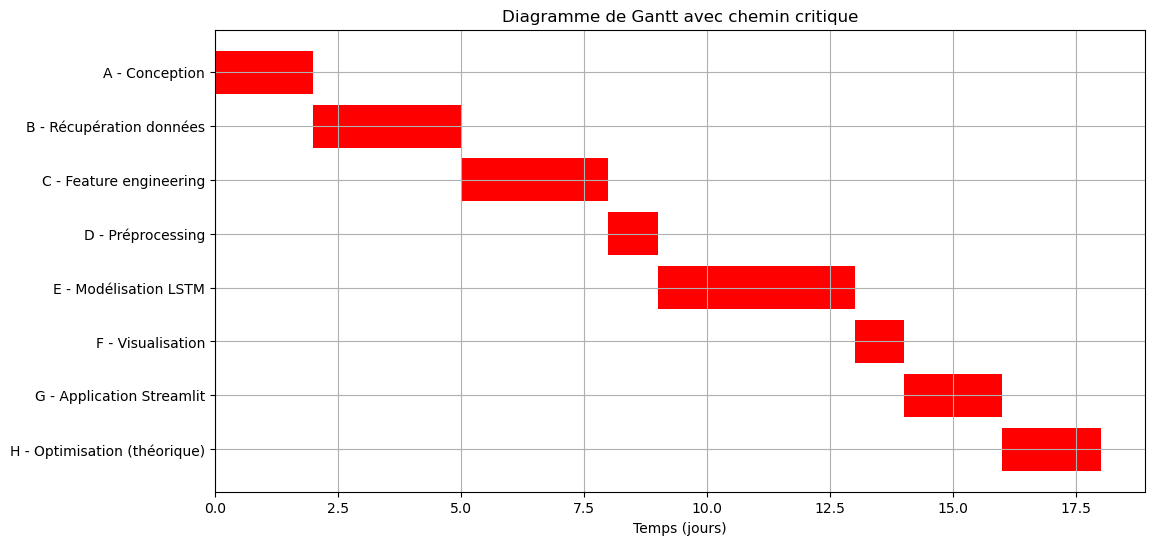

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(len(tasks)):
    couleur = "red" if tasks.loc[i, "Critique"] else "blue"
    
    plt.barh(
        tasks.loc[i, "Tache"],
        tasks.loc[i, "Duree"],
        left=tasks.loc[i, "ES"],
        color=couleur
    )

plt.xlabel("Temps (jours)")
plt.title("Diagramme de Gantt avec chemin critique")

plt.gca().invert_yaxis()
plt.grid()

plt.show()

In [15]:
risques = pd.DataFrame({
    "Tache": tasks["Tache"],
    "Risque": [
        "Mauvaise définition du problème",
        "API instable",
        "Indicateurs non pertinents",
        "Données mal normalisées",
        "Surapprentissage",
        "Mauvaise interprétation",
        "Bug interface",
        "Partie non implémentée"
    ],
    "Impact": ["Fort","Fort","Moyen","Moyen","Fort","Moyen","Faible","Fort"],
    "Probabilité": ["Moyenne","Moyenne","Moyenne","Faible","Moyenne","Faible","Faible","Élevée"]
})

risques

,Tache,Risque,Impact,Probabilité
0,A - Conception,Mauvaise définition du problème,Fort,Moyenne
1,B - Récupération données,API instable,Fort,Moyenne
2,C - Feature engineering,Indicateurs non pertinents,Moyen,Moyenne
3,D - Préprocessing,Données mal normalisées,Moyen,Faible
4,E - Modélisation LSTM,Surapprentissage,Fort,Moyenne
5,F - Visualisation,Mauvaise interprétation,Moyen,Faible
6,G - Application Streamlit,Bug interface,Faible,Faible
7,H - Optimisation (théorique),Partie non implémentée,Fort,Élevée
